# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

Se generaron 23 puntos aleatorios en [0, 5].


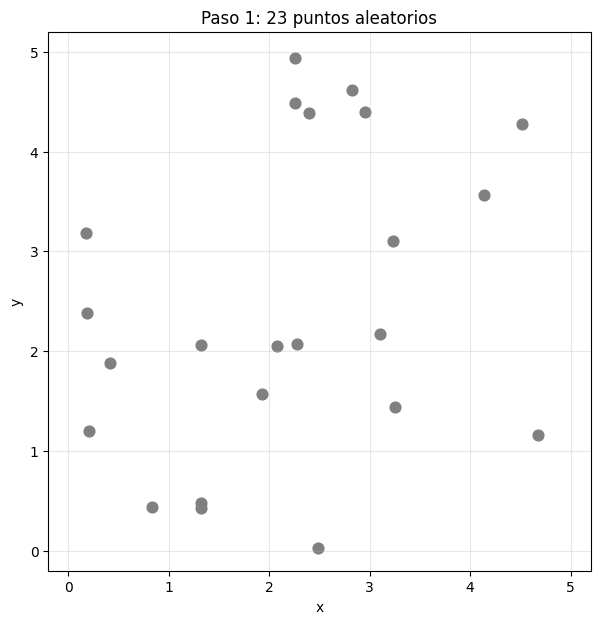


=== Centroides iniciales ===
Ingresá cada centroide como 'x y' (valores entre 0 y 5).
Presioná Enter sin escribir nada para elegir uno al azar.

  -> aleatorio: (2.398, 4.388)
  -> aleatorio: (1.325, 2.058)


K-Means convergió en 2 iteraciones (sobre 20 puntos).
  Centroide final 0: (3.050, 4.381)  -> 7 puntos
  Centroide final 1: (1.369, 1.478)  -> 13 puntos

Puntos a clasificar con KNN (más cercanos a la equidistancia):
  P1 (3.11, 2.18)  d0=2.206  d1=1.871  distancia a la frontera=0.203
  P2 (4.67, 1.16)  d0=3.604  d1=3.319  distancia a la frontera=0.294
  P3 (3.23, 3.10)  d0=1.290  d1=2.471  distancia a la frontera=0.662

Valores de K a evaluar: [1, 3, 5, 6, 9]

--- K = 1 ---
  P1 (3.11, 2.18) -> Grupo 1 (Azul)   [votos: Rojo=0, Azul=1]
  P2 (4.67, 1.16) -> Grupo 1 (Azul)   [votos: Rojo=0, Azul=1]
  P3 (3.23, 3.10) -> Grupo 0 (Rojo)   [votos: Rojo=1, Azul=0]

--- K = 3 ---
  P1 (3.11, 2.18) -> Grupo 1 (Azul)   [votos: Rojo=0, Azul=3]
  P2 (4.67, 1.16) -> Grupo 1 (Azul)   [votos: R

In [1]:
"""
K-Means (20 puntos, 2 grupos) + KNN (3 puntos restantes, K en [1, 3, 5, 6, 9]).

Los 3 puntos que se clasifican con KNN pueden elegirse de dos maneras
(pregunta S/n, por defecto Sí):
  - Sí: los 3 puntos más cercanos a ser equidistantes de ambos centroides
        (los más "ambiguos"), para que el efecto de K se note más.
  - No: simplemente los 3 últimos puntos generados.

K-Means y KNN están implementados desde cero con NumPy (sin sklearn).
Requisitos: pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------- #
# Generación de datos
# --------------------------------------------------------------------------- #
class PointGenerator:
    """Genera puntos 2D aleatorios en el intervalo [low, high]."""

    def __init__(self, n_points=23, low=0.0, high=5.0, seed=None):
        self.n_points = n_points
        self.low = low
        self.high = high
        self.rng = np.random.default_rng(seed)

    def generate(self):
        return self.rng.uniform(self.low, self.high, size=(self.n_points, 2))


# --------------------------------------------------------------------------- #
# K-Means
# --------------------------------------------------------------------------- #
class KMeans:
    """Implementación de K-Means (algoritmo de Lloyd)."""

    def __init__(self, n_clusters=2, max_iter=300, tol=1e-9):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
        self.labels_ = None
        self.n_iter_ = 0

    @staticmethod
    def distances(X, centroids):
        """Matriz (n_puntos x n_centroides) de distancias euclídeas."""
        return np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)

    def fit(self, X, initial_centroids):
        X = np.asarray(X, dtype=float)
        centroids = np.array(initial_centroids, dtype=float)

        for i in range(1, self.max_iter + 1):
            # 1) Asignación: cada punto al centroide más cercano
            labels = np.argmin(self.distances(X, centroids), axis=1)

            # 2) Actualización: nuevo centroide = media del grupo
            new_centroids = centroids.copy()
            for k in range(self.n_clusters):
                members = X[labels == k]
                if len(members) > 0:          # si un grupo queda vacío, se conserva
                    new_centroids[k] = members.mean(axis=0)

            # 3) Convergencia
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            self.n_iter_ = i
            if shift <= self.tol:
                break

        self.centroids = centroids
        self.labels_ = np.argmin(self.distances(X, centroids), axis=1)
        return self


# --------------------------------------------------------------------------- #
# KNN
# --------------------------------------------------------------------------- #
class KNNClassifier:
    """Clasificador K-Nearest Neighbors (distancia euclídea, voto por mayoría)."""

    def __init__(self):
        self.X = None
        self.y = None

    def fit(self, X, y):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y, dtype=int)
        return self

    def predict_one(self, point, k):
        """
        Devuelve (etiqueta, índices_vecinos, distancias_vecinos).
        Desempate (posible con K par, ej. K=6 con 3 vs 3):
        gana el grupo cuya suma de distancias a sus vecinos sea menor.
        """
        dists = np.linalg.norm(self.X - point, axis=1)
        idx = np.argsort(dists)[:k]
        neighbor_labels = self.y[idx]

        classes, counts = np.unique(neighbor_labels, return_counts=True)
        winners = classes[counts == counts.max()]

        if len(winners) == 1:
            label = winners[0]
        else:
            sums = {c: dists[idx][neighbor_labels == c].sum() for c in winners}
            label = min(sums, key=sums.get)

        return int(label), idx, dists[idx]


# --------------------------------------------------------------------------- #
# Visualización
# --------------------------------------------------------------------------- #
class Plotter:
    """Se encarga de todos los gráficos."""

    COLORS = {0: "red", 1: "blue"}
    NAMES = {0: "Grupo 0 (Rojo)", 1: "Grupo 1 (Azul)"}

    def __init__(self):
        plt.ion()
        self.fig, self.ax = plt.subplots(figsize=(7, 7))

    def _setup(self, title):
        self.ax.clear()
        self.ax.set_xlim(-0.2, 5.2)
        self.ax.set_ylim(-0.2, 5.2)
        self.ax.set_xlabel("x")
        self.ax.set_ylabel("y")
        self.ax.set_title(title)
        self.ax.grid(True, alpha=0.3)

    def _refresh(self):
        self.fig.canvas.draw_idle()
        plt.pause(0.1)

    def _draw_groups(self, X, labels):
        for k, color in self.COLORS.items():
            pts = X[labels == k]
            self.ax.scatter(pts[:, 0], pts[:, 1], c=color, s=60,
                            label=self.NAMES[k], alpha=0.8)

    def _draw_centroids(self, centroids):
        for k, c in enumerate(centroids):
            self.ax.scatter(c[0], c[1], c=self.COLORS[k], marker="X", s=250,
                            edgecolors="black", linewidths=1.5,
                            label=f"Centroide {k}")

    def _draw_boundary(self, centroids):
        """Mediatriz entre los dos centroides: puntos equidistantes."""
        c0, c1 = centroids
        v = c1 - c0
        norm = np.linalg.norm(v)
        if norm < 1e-12:
            return
        mid = (c0 + c1) / 2
        direction = np.array([-v[1], v[0]]) / norm
        t = np.array([-10.0, 10.0])
        line = mid[None, :] + t[:, None] * direction[None, :]
        self.ax.plot(line[:, 0], line[:, 1], "k--", linewidth=1, alpha=0.6,
                     label="Equidistancia entre centroides")

    def _draw_pending(self, pending):
        self.ax.scatter(pending[:, 0], pending[:, 1], c="black", marker="*",
                        s=250, label="Puntos sin clasificar")
        for i, p in enumerate(pending):
            self.ax.annotate(f"P{i + 1}", p, textcoords="offset points",
                             xytext=(8, 8), fontweight="bold")

    def show_raw(self, X):
        self._setup("Paso 1: 23 puntos aleatorios")
        self.ax.scatter(X[:, 0], X[:, 1], c="gray", s=60)
        self._refresh()

    def show_kmeans(self, X_train, labels, centroids, pending, n_iter):
        self._setup(f"Paso 2: K-Means (2 grupos, {n_iter} iteraciones)")
        self._draw_groups(X_train, labels)
        self._draw_centroids(centroids)
        self._draw_boundary(centroids)
        self._draw_pending(pending)
        self.ax.legend(loc="upper right", fontsize=8)
        self._refresh()

    def show_knn(self, X_train, y_train, centroids, pending, pred_labels,
                 neighbors, k):
        self._setup(f"Paso 3: KNN con K = {k}")
        self._draw_groups(X_train, y_train)
        self._draw_boundary(centroids)
        for i, p in enumerate(pending):
            color = self.COLORS[pred_labels[i]]
            # líneas hacia los K vecinos usados
            for j in neighbors[i]:
                self.ax.plot([p[0], X_train[j, 0]], [p[1], X_train[j, 1]],
                             color=color, alpha=0.35, linewidth=1)
            self.ax.scatter(p[0], p[1], c=color, marker="*", s=350,
                            edgecolors="black", linewidths=1.5)
            self.ax.annotate(f"P{i + 1}", p, textcoords="offset points",
                             xytext=(10, 10), fontweight="bold")
        self.ax.legend(loc="upper right", fontsize=8)
        self._refresh()


# --------------------------------------------------------------------------- #
# Aplicación principal
# --------------------------------------------------------------------------- #
class Application:
    N_POINTS = 23
    N_TRAIN = 20
    N_CLUSTERS = 2
    K_VALUES = [1, 3, 5, 6, 9]

    def __init__(self, seed=None):
        self.points = PointGenerator(self.N_POINTS, 0, 5, seed).generate()
        self.X_train = None      # 20 puntos -> K-Means
        self.X_pending = None    # 3 puntos  -> KNN
        self.plotter = Plotter()
        self.rng = np.random.default_rng(seed)

    # ---- entradas por consola -------------------------------------------- #
    def _ask_centroids(self):
        print("\n=== Centroides iniciales ===")
        print("Ingresá cada centroide como 'x y' (valores entre 0 y 5).")
        print("Presioná Enter sin escribir nada para elegir uno al azar.\n")

        centroids = []
        for k in range(self.N_CLUSTERS):
            while True:
                raw = input(f"Centroide {k} (x y): ").strip().replace(",", " ")
                if raw == "":
                    c = self.points[self.rng.integers(len(self.points))]
                    print(f"  -> aleatorio: ({c[0]:.3f}, {c[1]:.3f})")
                    centroids.append(c)
                    break
                try:
                    x, y = map(float, raw.split())
                    centroids.append(np.array([x, y]))
                    break
                except ValueError:
                    print("  Entrada inválida. Ejemplo: 1.5 3.2")
        return np.array(centroids)

    @staticmethod
    def _ask_yes_no(prompt, default=True):
        hint = "[S/n]" if default else "[s/N]"
        while True:
            raw = input(f"{prompt} {hint}: ").strip().lower()
            if raw == "":
                return default
            if raw in ("s", "si", "sí", "y", "yes"):
                return True
            if raw in ("n", "no"):
                return False
            print("  Respondé con S o N (Enter = opción predefinida).")

    # ---- división entrenamiento / pendientes ------------------------------ #
    @staticmethod
    def _boundary_distance(points, centroids):
        """Distancia de cada punto a la mediatriz entre los dos centroides
        (0 = perfectamente equidistante)."""
        c0, c1 = centroids
        d0 = np.linalg.norm(points - c0, axis=1)
        d1 = np.linalg.norm(points - c1, axis=1)
        sep = max(np.linalg.norm(c1 - c0), 1e-12)
        return np.abs(d0 ** 2 - d1 ** 2) / (2 * sep)

    def _split_default(self, init):
        """20 primeros puntos -> K-Means, 3 últimos -> KNN."""
        train = self.points[:self.N_TRAIN]
        pending = self.points[self.N_TRAIN:]
        km = KMeans(self.N_CLUSTERS).fit(train, init)
        return train, pending, km, True

    def _split_by_ambiguity(self, init, max_rounds=20):
        """
        Elige como pendientes los puntos más cercanos a la equidistancia.
        Como los centroides dependen de los puntos de entrenamiento, se itera
        hasta que la selección sea estable:
          1) K-Means con los 23 puntos -> centroides provisorios
          2) se separan los 3 puntos más cercanos a la frontera
          3) K-Means con los 20 restantes -> centroides nuevos
          4) se repite desde 2) hasta que los 3 puntos no cambien
        Devuelve (X_train, X_pending, kmeans_final, estable).
        """
        n_pending = self.N_POINTS - self.N_TRAIN
        km = KMeans(self.N_CLUSTERS).fit(self.points, init)
        pending_idx, stable = None, False

        for _ in range(max_rounds):
            gap = self._boundary_distance(self.points, km.centroids)
            new_idx = np.argsort(gap)[:n_pending]      # el más ambiguo primero
            if pending_idx is not None and set(new_idx) == set(pending_idx):
                stable = True
                break
            pending_idx = new_idx
            mask = np.ones(self.N_POINTS, dtype=bool)
            mask[pending_idx] = False
            km = KMeans(self.N_CLUSTERS).fit(self.points[mask], init)

        mask = np.ones(self.N_POINTS, dtype=bool)
        mask[pending_idx] = False
        return self.points[mask], self.points[pending_idx], km, stable

    # ---- flujo del programa ---------------------------------------------- #
    def run(self):
        # 1) Puntos
        print(f"Se generaron {self.N_POINTS} puntos aleatorios en [0, 5].")
        self.plotter.show_raw(self.points)
        input("\n[Enter] para ejecutar K-Means...")

        # 2) Configuración + K-Means sobre 20 puntos
        init = self._ask_centroids()
        print()
        ambiguous = self._ask_yes_no(
            "¿Clasificar con KNN los puntos cercanos a la equidistancia "
            "entre centroides?", default=True)

        if ambiguous:
            self.X_train, self.X_pending, kmeans, stable = \
                self._split_by_ambiguity(init)
            if not stable:
                print("  Aviso: la selección no se estabilizó del todo; "
                      "se usa la última.")
        else:
            self.X_train, self.X_pending, kmeans, _ = self._split_default(init)

        print(f"\nK-Means convergió en {kmeans.n_iter_} iteraciones "
              f"(sobre {len(self.X_train)} puntos).")
        for k, c in enumerate(kmeans.centroids):
            n = int(np.sum(kmeans.labels_ == k))
            print(f"  Centroide final {k}: ({c[0]:.3f}, {c[1]:.3f})  -> {n} puntos")

        d = KMeans.distances(self.X_pending, kmeans.centroids)
        gap = self._boundary_distance(self.X_pending, kmeans.centroids)
        titulo = ("más cercanos a la equidistancia" if ambiguous
                  else "últimos 3 generados")
        print(f"\nPuntos a clasificar con KNN ({titulo}):")
        for i, p in enumerate(self.X_pending):
            print(f"  P{i + 1} ({p[0]:.2f}, {p[1]:.2f})  d0={d[i, 0]:.3f}  "
                  f"d1={d[i, 1]:.3f}  distancia a la frontera={gap[i]:.3f}")

        self.plotter.show_kmeans(self.X_train, kmeans.labels_, kmeans.centroids,
                                 self.X_pending, kmeans.n_iter_)

        # ------------------------- BREAKPOINT ------------------------------ #
        input("\n[BREAKPOINT] Enter para clasificar los 3 puntos restantes con KNN...")

        # 3) KNN para cada K
        knn = KNNClassifier().fit(self.X_train, kmeans.labels_)
        print(f"\nValores de K a evaluar: {self.K_VALUES}")

        for n, k in enumerate(self.K_VALUES):
            print(f"\n--- K = {k} ---")
            preds, neighbors = [], []
            for i, p in enumerate(self.X_pending):
                label, idx, _ = knn.predict_one(p, k)
                votes = np.bincount(kmeans.labels_[idx], minlength=self.N_CLUSTERS)
                preds.append(label)
                neighbors.append(idx)
                print(f"  P{i + 1} ({p[0]:.2f}, {p[1]:.2f}) -> "
                      f"{Plotter.NAMES[label]}   "
                      f"[votos: Rojo={votes[0]}, Azul={votes[1]}]")
            self.plotter.show_knn(self.X_train, kmeans.labels_, kmeans.centroids,
                                  self.X_pending, preds, neighbors, k)

            if n < len(self.K_VALUES) - 1:
                input(f"\n[BREAK] Enter para pasar a K = {self.K_VALUES[n + 1]}...")

        print("\nFin. Cerrá la ventana del gráfico para terminar.")
        plt.ioff()
        plt.show()


if __name__ == "__main__":
    # seed=None -> puntos distintos en cada ejecución. Poné un entero para reproducir.
    Application(seed=None).run()

#### Nota:
Debido a que la implementación anterior requiere entradas por teclado, y actualiza los graficos se añaden los resultados con anotaciones sobre estos

Primero, se generaron los puntos (cambian segun la ejecución):

![Puntos vacios.png](<attachment:Puntos vacios.png>)

Luego, se preguntan cuales centroides se quieren usar, y ademas se pregunta si se quieren usar los puntos mas cercanos a la equidistancia entre centroides como puntos a analizar (Esto debido a que serian los puntos mas interezantes a ver) (Como tecnicamente esto no es valido, se pone como opcion decir que No)

![Etapa Clasificacion.png](<attachment:Etapa Clasificacion.png>)

Luego, se hace la clasificacion con distintos Ks, mostrando cuales son los puntos tomados para seleccionar el grupo

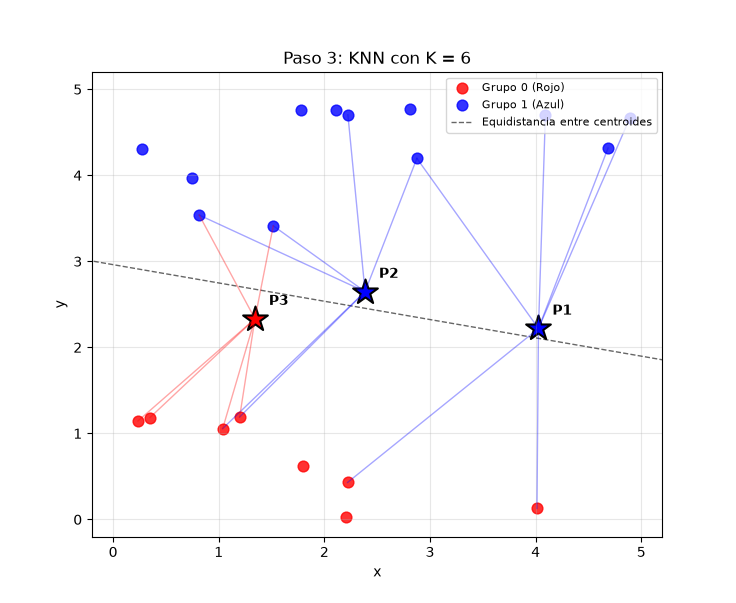
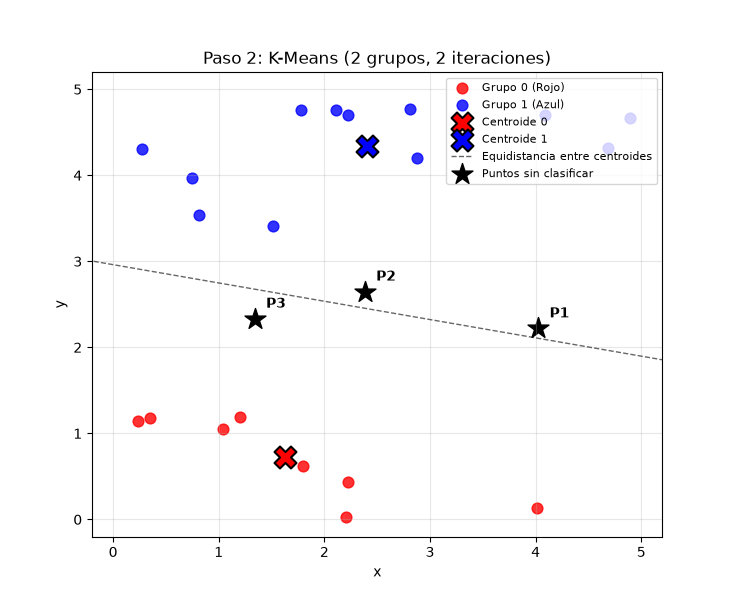
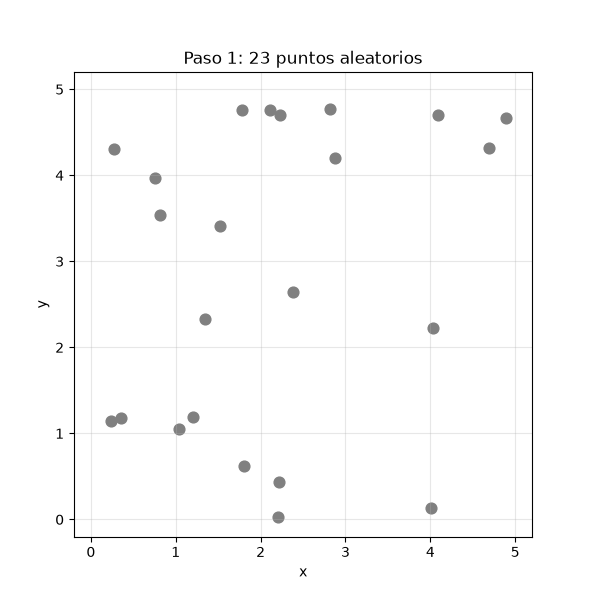

#### Prompt Utilizado
Eres un programador avanzado de Python, que toma una orientación de Programación orientada a objetos.

Tu deber es generar una implementación del algoritmo K Means usando numpy u otras librerías de calculo, pero No una biblioteca que tenga una implementación previa.
- Inicialmente genera un conjunto de 23 puntos que contengan coordenadas xy aleatorias con valores contenidos en el intervalo [0, 5]

- Luego, graficá los puntos en un grafico

- Con el algoritmo K-means, clasificá 20 de los 23 puntos en 2 grupos, y graficá el resultado asignando un color a cada uno (preferentemente Rojo y Azul).
	- Considerá preguntar los centroides iniciales por consola 
	- Para lograr una mejor visualización de el efecto de los K, implementá la opción de que los puntos a analizar sean los que están cercanos a equidistantes entre centroides. Tomalo como una pregunta Y/n, donde la opción predefinida es Sí

- Luego, añadí un breakpoint (preferentemente con un simple input)

- Después de ése breakpoint, Tomá los tres puntos restantes y clasifícalos en los grupos obtenidos anteriormente usando el algoritmo Knn. 
	- Utilizá una lista con 5 distintos valores de K, [1, 3, 5, 6, 9], indicando cuales son por consola, graficándolos e indicando que tipo de grupo se le asignó por consola, y añadiendo un break entre distintos K.
	- En caso de empate, gana la menor suma de distancias

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

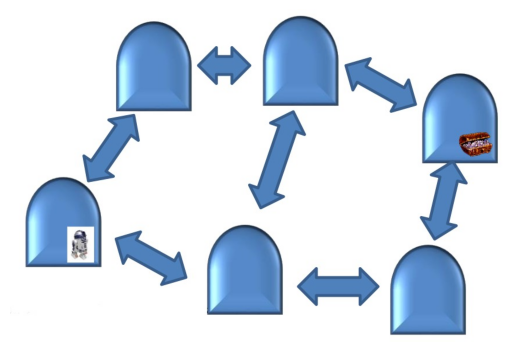

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)